Index | Cycles | Δ (diff from previous)
    0 |     627 | -
    1 |     720 |     93
    2 |     831 |    111
    3 |     890 |     59
    4 |    1031 |    141
    5 |    1126 |     95
    6 |    1237 |    111
    7 |    1266 |     29
    8 |    1413 |    147
    9 |    1524 |    111
   10 |    1633 |    109
   11 |    1688 |     55
   12 |    1815 |    127
   13 |    1915 |    100
   14 |    2026 |    111
   15 |    2052 |     26
   16 |    2197 |    145
   17 |    2293 |     96
   18 |    2415 |    122
   19 |    2444 |     29
   20 |    2580 |    136
   21 |    2686 |    106
   22 |    2810 |    124
   23 |    2823 |     13
   24 |    2958 |    135
   25 |    3079 |    121
   26 |    3182 |    103
   27 |    3216 |     34
   28 |    3353 |    137
   29 |    3466 |    113
   30 |    3583 |    117
   31 |    3581 |     -2
   32 |    3736 |    155
   33 |    3840 |    104
   34 |    3962 |    122
   35 |    3995 |     33
   36 |    4113 |    118
   37 |    4241 |    128
   38 |    4367

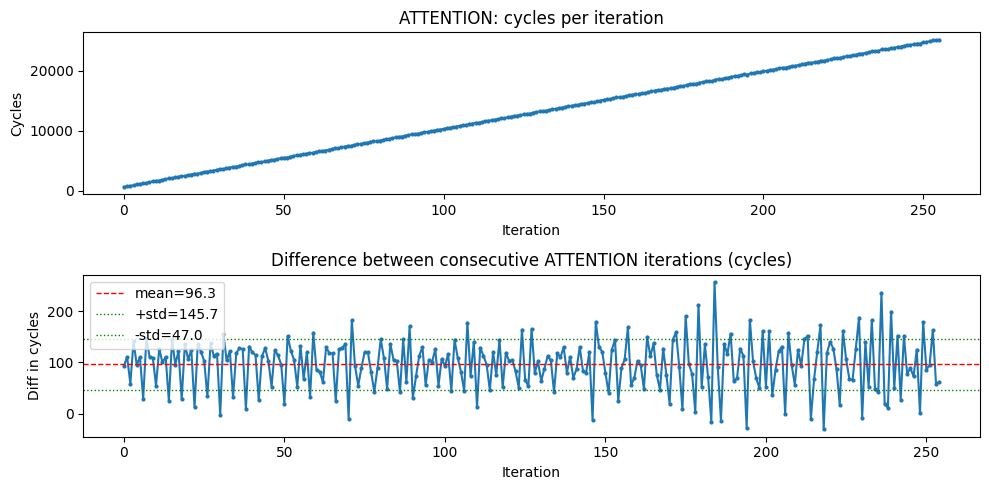

In [8]:
import matplotlib.pyplot as plt
import numpy as np

cycles = []
capture = False

with open("out.txt") as f:
    for line in f:
        line = line.strip()
        if line.startswith("ATTENTION:"):
            capture = True
            continue
        if capture:
            if line.startswith("[core 0] cycles ="):
                try:
                    val = int(line.split('=')[-1])
                    cycles.append(val)
                except ValueError:
                    pass
            elif line == "":
                capture = False

# --- Calcolo differenze ---
diffs = [cycles[i] - cycles[i-1] for i in range(1, len(cycles))]
mean_diff = np.mean(diffs)
std_diff = np.std(diffs)

# --- Stampa risultati ---
print("Index | Cycles | Δ (diff from previous)")
prev = None
for i, val in enumerate(cycles):
    if prev is None:
        print(f"{i:5d} | {val:7d} | -")
    else:
        diff = val - prev
        print(f"{i:5d} | {val:7d} | {diff:6d}")
    prev = val

print(f"\nMean increase: {mean_diff:.2f} cycles")
print(f"Standard deviation: {std_diff:.2f} cycles")

# --- Plot ---
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(cycles, marker='o', markersize=2)
plt.title("ATTENTION: cycles per iteration")
plt.xlabel("Iteration")
plt.ylabel("Cycles")

plt.subplot(2,1,2)
plt.plot(diffs, marker='o', markersize=2)
plt.axhline(mean_diff, color='r', linestyle='--', linewidth=1, label=f"mean={mean_diff:.1f}")
plt.axhline(mean_diff + std_diff, color='g', linestyle=':', linewidth=1, label=f"+std={mean_diff+std_diff:.1f}")
plt.axhline(mean_diff - std_diff, color='g', linestyle=':', linewidth=1, label=f"-std={mean_diff-std_diff:.1f}")
plt.title("Difference between consecutive ATTENTION iterations (cycles)")
plt.xlabel("Iteration")
plt.ylabel("Diff in cycles")
plt.legend()
plt.tight_layout()
plt.show()
